In [1]:
import numpy as np
from pysr import *

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# Setting Up the Data

X = 2 * np.random.randn(100, 5)
y = 2 * np.cos(X[:, 3]) + X[:, 0] ** 2 - 2

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from pysr import PySRRegressor

model = PySRRegressor(
    niterations=500,
    population_size=50,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[
        "inv(x) = 1/x"
    ],
    extra_sympy_mappings={
        "inv": lambda x: 1/x,
    },
    temp_equation_file=True,
)


model.fit(X_train, y_train)

/home/voodobard/programing/lamfo/ic_andre_rimes/env/lib/python3.10/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.810e+05
Progress: 834 / 15500 total iterations (5.381%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.670e+01  0.000e+00  y = 1.9265
3           5.094e+00  8.282e-01  y = x₀ * x₀
5           1.760e+00  5.313e-01  y = (x₀ * x₀) - 1.8259
7           1.671e+00  2.597e-02  y = ((x₀ * x₀) - 1.9409) * 1.0635
9           1.656e+00  4.692e-03  y = (((x₀ + 0.062415) * 1.0583) * x₀) + -2.0579
10          1.498e+00  9.987e-02  y = ((x₀ * x₀) + inv(x₃ + -4.2566)) - 1.4708
12          1.370e+00  4.494e-02  y = ((inv(x₃ + -4.233) + (x₀ * x₀)) * 1.0771) - 1.7255
13          1.283e+00  6.570e-02  y = ((x₀ * x₀) - (((-2.9083 - x₃) * -0.10009) * x₃)) - 1.2...
                                      966
14          1.271e+00  9.232e-03  y = ((x₀ * x₀) + ((inv(x₃

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,['inv(x) = 1/x']
,expression_spec,None
,niterations,500
,populations,31
,population_size,50
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [28]:
from sklearn.metrics import mean_squared_error as MSE

y_pred = model.predict(X_test)

rmse = (MSE(y_test, y_pred))**0.5
print(rmse)

0.011249813677357026
Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

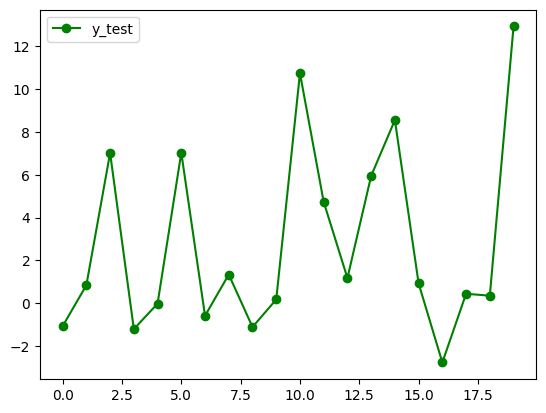

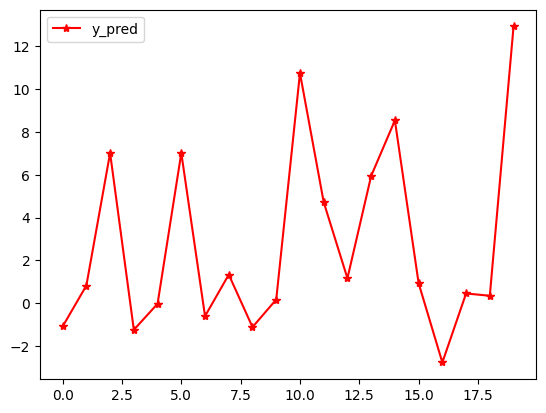

(20,)
(20,)
Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe2 in position 4095: unexpected end of data

In [29]:
import matplotlib.pyplot as plt
x_axis = np.arange(len(y_test))

plt.plot(x_axis, y_test.flatten(), color='g', marker="o", label='y_test')
plt.legend()
plt.show()


plt.plot(x_axis, y_pred.flatten(), color='r', marker="*", label='y_pred')
plt.legend()
plt.show()

print(y_test.shape)
print(y_pred.shape)
